## Importing Modules

In [5]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

## Loading Data Sets

In [8]:
paths=[]
labels=[]
for dirname,_,filenames in os.walk('./datasets2/archive/TESS Toronto emotional speech set data/'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
        label=filename.split('_')[-1]
        label=label.split('.')[0]
        labels.append(label.lower())
print('datasets is loaded')

datasets is loaded


In [10]:
paths[:5]

['./datasets2/archive/TESS Toronto emotional speech set data/OAF_angry\\OAF_back_angry.wav',
 './datasets2/archive/TESS Toronto emotional speech set data/OAF_angry\\OAF_bar_angry.wav',
 './datasets2/archive/TESS Toronto emotional speech set data/OAF_angry\\OAF_base_angry.wav',
 './datasets2/archive/TESS Toronto emotional speech set data/OAF_angry\\OAF_bath_angry.wav',
 './datasets2/archive/TESS Toronto emotional speech set data/OAF_angry\\OAF_bean_angry.wav']

In [12]:
labels[:5]

['angry', 'angry', 'angry', 'angry', 'angry']

## creating dataframe

In [15]:
df=pd.DataFrame()
df['speech']=paths
df['labels']=labels
df.head()

,speech,labels
0,./datasets2/archive/TESS Toronto emotional spe...,angry
1,./datasets2/archive/TESS Toronto emotional spe...,angry
2,./datasets2/archive/TESS Toronto emotional spe...,angry
3,./datasets2/archive/TESS Toronto emotional spe...,angry
4,./datasets2/archive/TESS Toronto emotional spe...,angry


In [17]:
df['labels'].value_counts()

labels
angry      800
disgust    800
fear       800
happy      800
neutral    800
ps         800
sad        800
Name: count, dtype: int64

## EDA

<Axes: xlabel='count', ylabel='labels'>

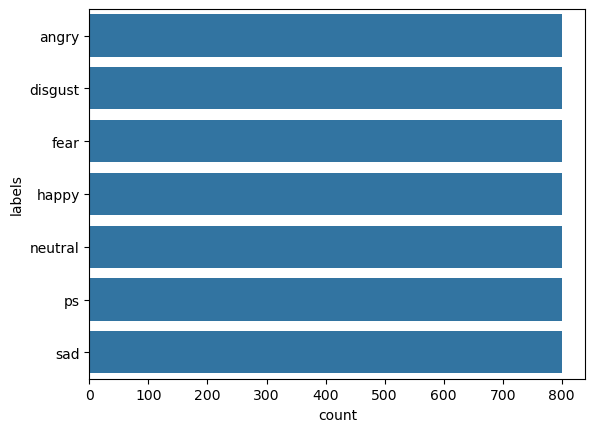

In [20]:
sns.countplot(df['labels'])

In [22]:
def waveplot(data,sr, emotion):
    plt.figure(figsize=(11,4))
    plt.title(emotion,size=20)
    librosa.display.waveshow(data,sr=sr)
    plt.show()
def spectogram(data,sr,emotion):
    x=librosa.stft(data)
    xdb=librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion,size=20)
    librosa.display.specshow(xdb,sr=sr,x_axis='time',y_axis='hz')
    plt.colorbar()
    plt.show()
    

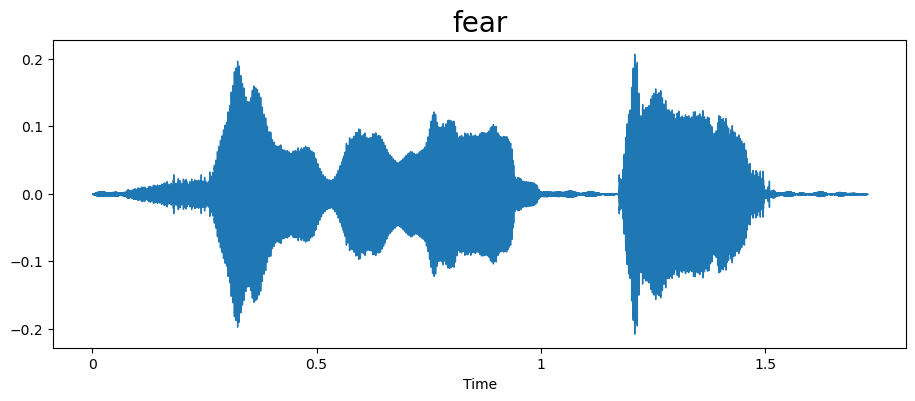

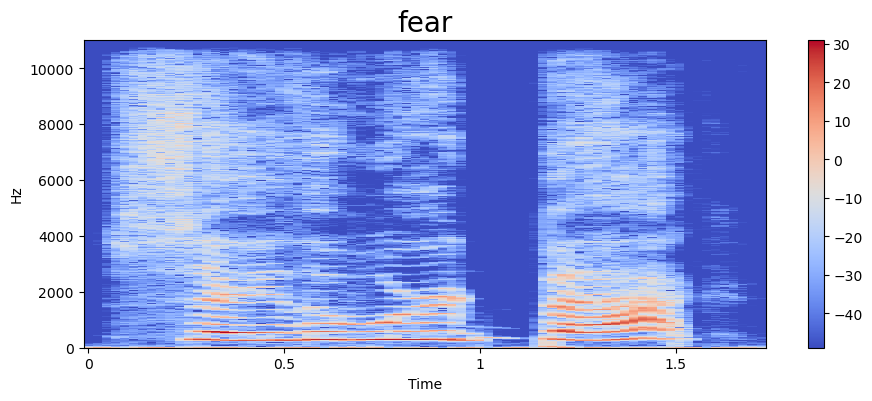

In [24]:
emotion='fear'
path=df['speech'][df['labels']==emotion].iloc[0]
data,sampling_rate= librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectogram(data,sampling_rate,emotion)
Audio(path)

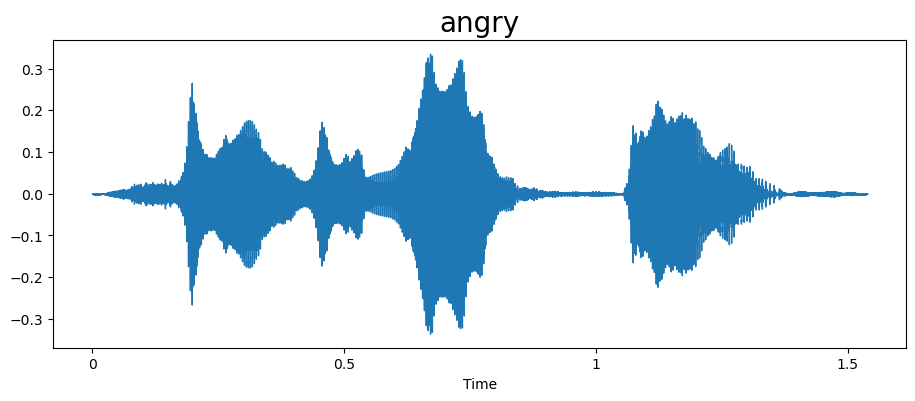

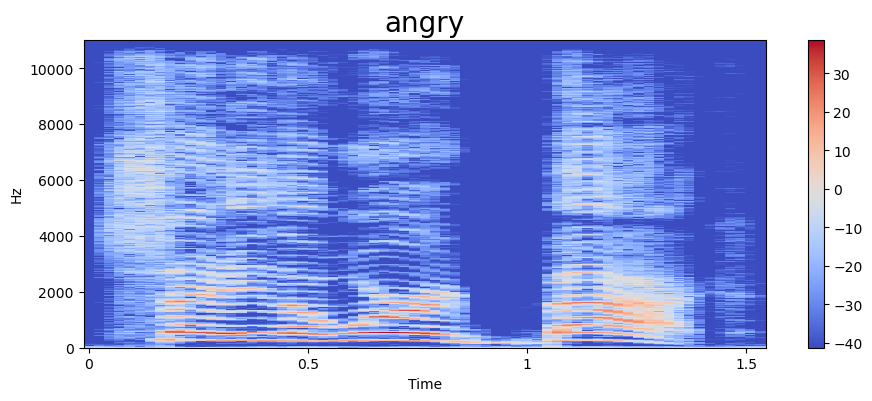

In [26]:
emotion='angry'
path=df['speech'][df['labels']==emotion].iloc[0]
data,sampling_rate= librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectogram(data,sampling_rate,emotion)
Audio(path)

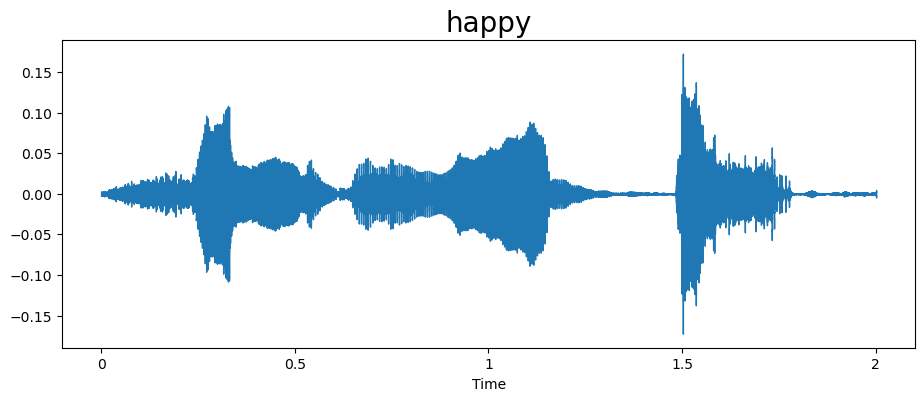

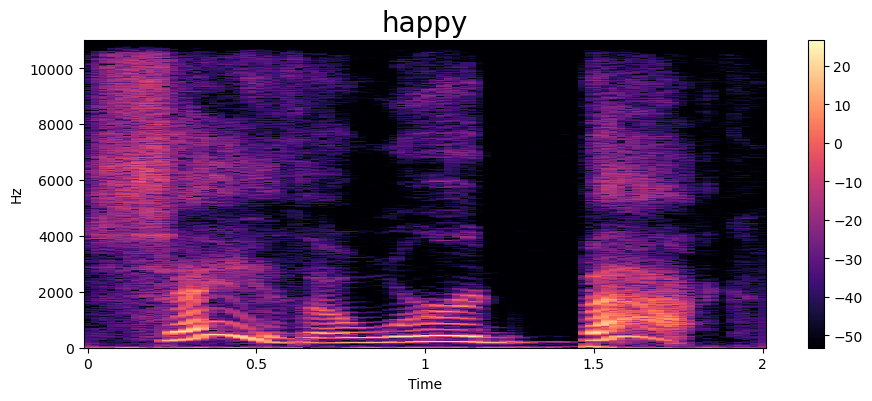

In [28]:
emotion='happy'
path=df['speech'][df['labels']==emotion].iloc[0]
data,sampling_rate= librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectogram(data,sampling_rate,emotion)
Audio(path)

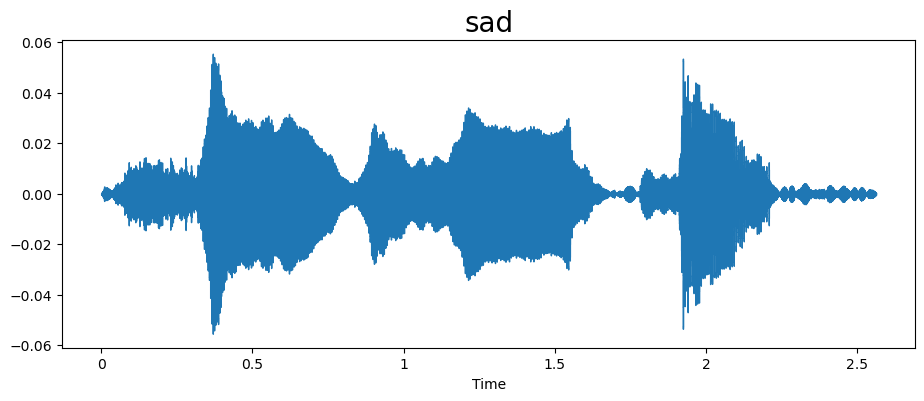

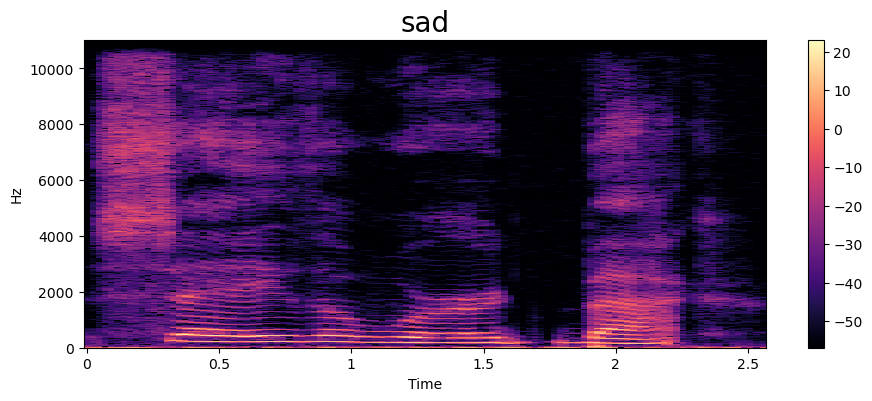

In [30]:
emotion='sad'
path=df['speech'][df['labels']==emotion].iloc[0]
data,sampling_rate= librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectogram(data,sampling_rate,emotion)
Audio(path)

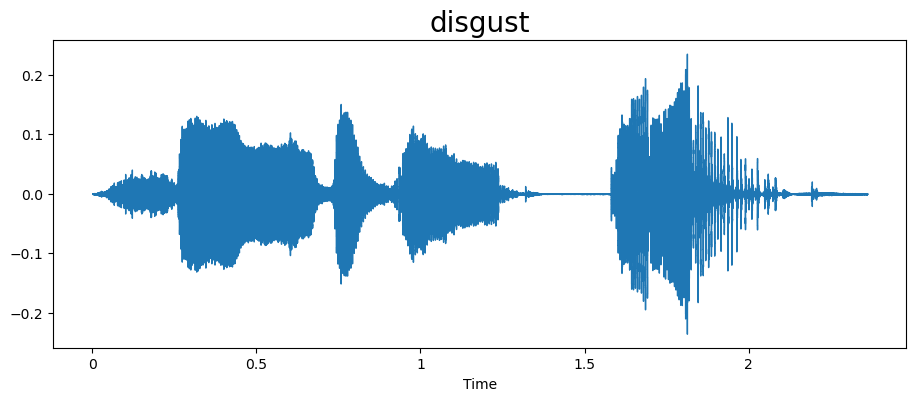

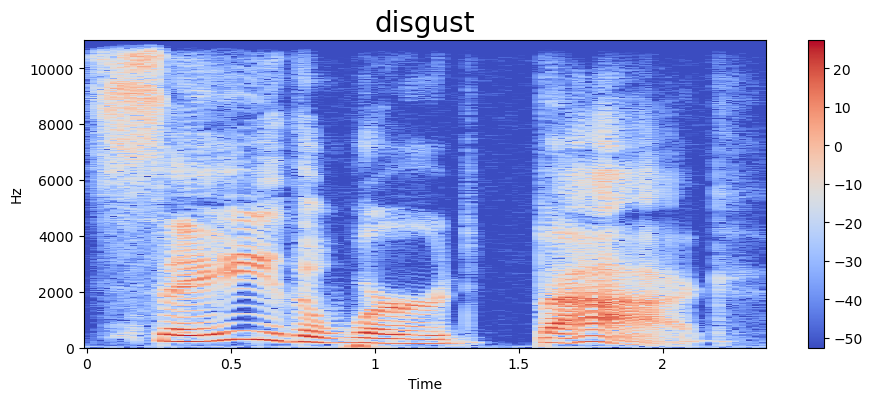

In [32]:
emotion='disgust'
path=df['speech'][df['labels']==emotion].iloc[600]
data,sampling_rate= librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectogram(data,sampling_rate,emotion)
Audio(path)

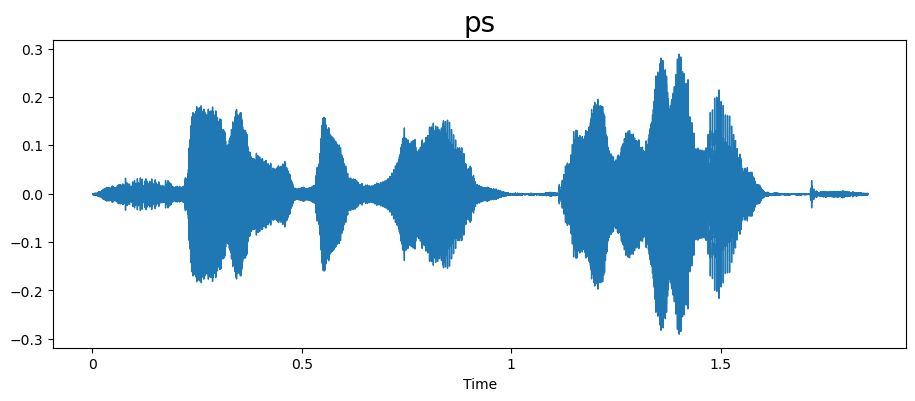

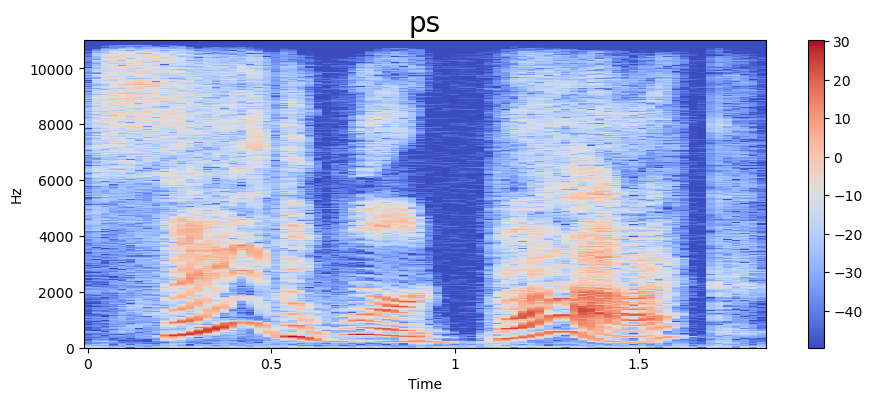

In [34]:
emotion='ps'
path=df['speech'][df['labels']==emotion].iloc[600]
data,sampling_rate= librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectogram(data,sampling_rate,emotion)
Audio(path)

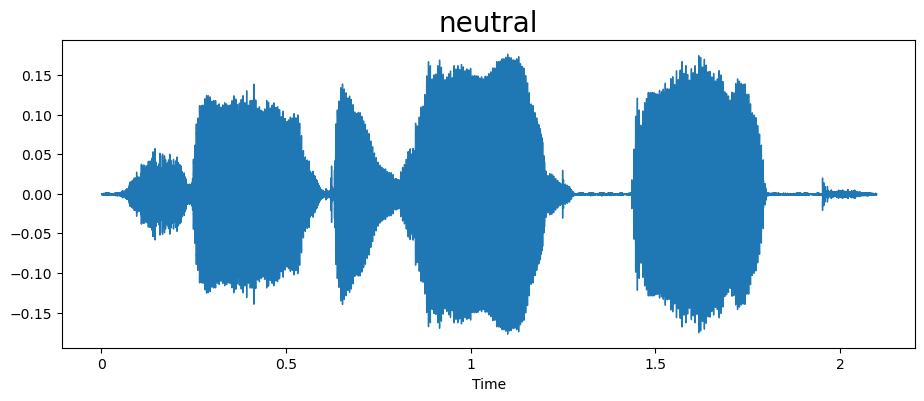

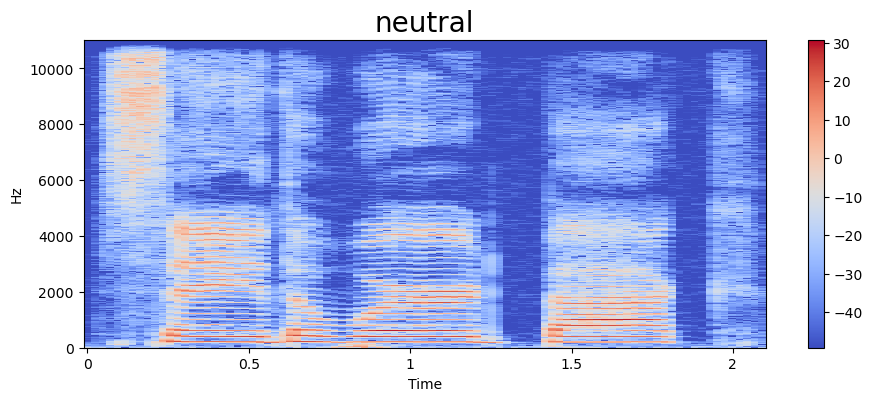

In [36]:
emotion='neutral'
path=df['speech'][df['labels']==emotion].iloc[600]
data,sampling_rate= librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectogram(data,sampling_rate,emotion)
Audio(path)

## Feature Exctraction

In [38]:
def extract_mfcc(filename):
    y, sr=librosa.load(filename,duration=3,offset=0.5)
    mfcc=np.mean(librosa.feature.mfcc(y=y,sr=sr,n_mfcc=40).T,axis=0)
    return mfcc

In [40]:
extract_mfcc(df['speech'][0])

array([-3.9698621e+02,  7.7440536e+01, -1.9592791e+01, -2.1666689e+01,
       -2.1127567e+00,  1.0075363e+01, -2.0366707e+01, -6.0924492e+00,
       -7.2122831e+00, -5.5736601e-01, -1.8325533e+00,  2.0210160e-01,
        7.2755092e-01,  1.3177377e+00,  2.8863373e+00,  2.8557909e+00,
       -4.7129216e+00, -4.4365101e+00, -1.6211591e+00, -1.0239839e+01,
       -7.5512629e+00, -1.7968802e+00, -7.0376525e+00,  9.4365835e+00,
        8.3558550e+00,  2.1712360e+01,  1.9216991e+01,  2.0348927e+01,
        1.3413366e+01,  8.3391724e+00,  3.9472201e-01,  5.1113148e+00,
        9.5687389e+00,  5.4548678e+00,  2.5099638e+00, -1.8239071e+00,
        4.8689623e+00,  9.3139238e+00,  2.0891500e+00, -1.9064913e+00],
      dtype=float32)

In [ ]:
X_mfcc=df['speech'].apply(lambda x : extract_mfcc(x))

In [ ]:
X_mfcc

In [ ]:
X=[x for x in X_mfcc]
X=np.array(X)
X.shape

In [ ]:
## input split
X = np.expand_dims(X,-1)
X.shape

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y= enc.fit_transform(df[['labels']])

In [ ]:
y=y.toarray()

In [ ]:
y.shape

## Creating LSTM model

In [204]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
model=Sequential([
    LSTM(123,return_sequences=False, input_shape=(40,1)),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dropout(0.2),
    Dense(7, activation = 'softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 123)                 │          61,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           7,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,747 (280.26 KB)

 Trainable params: 71,747 (280.26 KB)

 Non-trainable params: 0 (0.00 B)

In [208]:
## trainig the model
history = model.fit(X,y,validation_split=0.2,epochs=100,batch_size=512,shuffle=True)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.2054 - loss: 1.8880 - val_accuracy: 0.3920 - val_loss: 1.8055
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.3938 - loss: 1.6590 - val_accuracy: 0.5437 - val_loss: 1.5258
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.5234 - loss: 1.3352 - val_accuracy: 0.5089 - val_loss: 1.0775
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6223 - loss: 1.0144 - val_accuracy: 0.6580 - val_loss: 0.8086
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.7141 - loss: 0.7642 - val_accuracy: 0.7759 - val_loss: 0.5769
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.7806 - loss: 0.5959 - val_accuracy: 0.8188 - val_loss: 0.4088
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8295 - loss: 0.4554 - val_accuracy: 0.8839 - val_loss: 0.3072
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.8772 - loss: 0.3607 - val_accuracy: 0.8938 - val_loss

## plotting the result

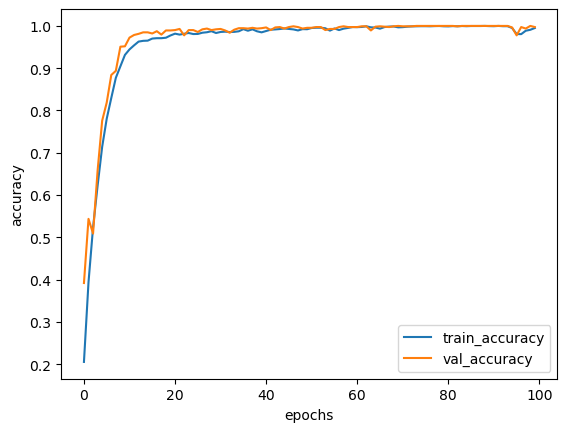

In [213]:
epochs=list(range(100))
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
plt.plot(epochs,acc,label='train_accuracy')
plt.plot(epochs,val_acc,label='val_accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
loss=history.history['loss']
val_acc=history.history['val_']
plt.plot(epochs,acc,label='train_accuracy')
plt.plot(epochs,val_acc,label='val_accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()